# Multi-Layer Perceptron Neural Network (Pytorch)

## 0. Installation & Imports 

### Torch Installation (MPS)

In [4]:
import torch

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print("MPS device not found.")

tensor([1.], device='mps:0')


### Import Libraries 

In [5]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
from IPython.display import HTML, display
from pprint import pprint

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 7)

# Machine Learning Libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from tqdm import tqdm  # progress bar

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


### Device Agnostic Code

In [6]:
device = "mps" if torch.mps.is_available() else "cpu"
print(f"✅ Using device: {device}")

✅ Using device: mps


## 1. Read Data

In [7]:
df1 = pd.read_csv("data/processed/creditcard_cleaned.csv")
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# some stats about the data
print(f"Number of Data Points: {df1.size}")
print(f"Number of Fradulent Transactions: {df1['Class'].value_counts()[1]}")
print(f"Number of Non-Fradulent Transactions: {df1['Class'].value_counts()[0]}\n")

Number of Data Points: 8795506
Number of Fradulent Transactions: 473
Number of Non-Fradulent Transactions: 283253



## 2. Stratified Splitting 

In [9]:
X = df1.drop(columns=["Class"])
y = df1["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
# - Check Class Distribution -
print(y_train.value_counts())
print("==========================")
print(y_test.value_counts())

Class
0    226602
1       378
Name: count, dtype: int64
Class
0    56651
1       95
Name: count, dtype: int64


## 3. Feature Scaling 

In [11]:
# - Scaling of Train, Validation, Test Data  -
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()  # set_output(transform="pandas") shouldn't work here (Conversion to Tensor won't work)

# - Train StandardScaler() based on features in Train Data -
X_train_scaled = scaler.fit_transform(X_train)

# - Apply Learning to Test Data -
X_test_scaled = scaler.transform(X_test)

In [12]:
# - Check Scaling Validity Manually -
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

Feature means after scaling:
 0.04211337257935192

Feature std devs after scaling:
 1.4115090716241605
Feature means after scaling:
 0.04118829144075911

Feature std devs after scaling:
 1.4687385481030577


## 4. Data Preparation 

We will now be converting our training / testing inputs and labels to tensors, which allows Pytorch objects such as `Dataset` and `DataLoader` to interpret them, and distribute them to our neural network in the correct data type.

In [13]:
from torch.utils.data import TensorDataset

X_train_ts = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_ts = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_ts = torch.tensor(y_train.values, dtype=torch.int64)
y_test_ts = torch.tensor(y_test.values, dtype=torch.int64)
train_data = TensorDataset(
    X_train_ts, y_train_ts
)  # auto pairs 1st value of X_train with y_train

# For Features (X): Use FloatTensor (or torch.float32)
# For Classification Labels (y): Use LongTensor (or torch.int64)
# For Regression Targets (y): Use FloatTensor (or torch.float32)

In [14]:
print("Train Data")
print("=" * 25)
print(f"Features dtype: {X_train_ts.dtype}")
print(f"Labels dtype: {y_train_ts.dtype}")

# 5. Check shapes
print(f"X_train Tensor Shape: {X_train_ts.shape}")
print(f"y_train Tensor Shape: {y_train_ts.shape}\n")

print("Test Data")
print("=" * 25)
print(f"Features dtype: {X_test_ts.dtype}")
print(f"Labels dtype: {y_test_ts.dtype}")
print(f"X_test Tensor Shape: {X_test_ts.shape}")
print(f"y_test Tensor Shape: {y_test_ts.shape}")

Train Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_train Tensor Shape: torch.Size([226980, 30])
y_train Tensor Shape: torch.Size([226980])

Test Data
Features dtype: torch.float32
Labels dtype: torch.int64
X_test Tensor Shape: torch.Size([56746, 30])
y_test Tensor Shape: torch.Size([56746])


## 5. Baseline MLP Neural Network Definition
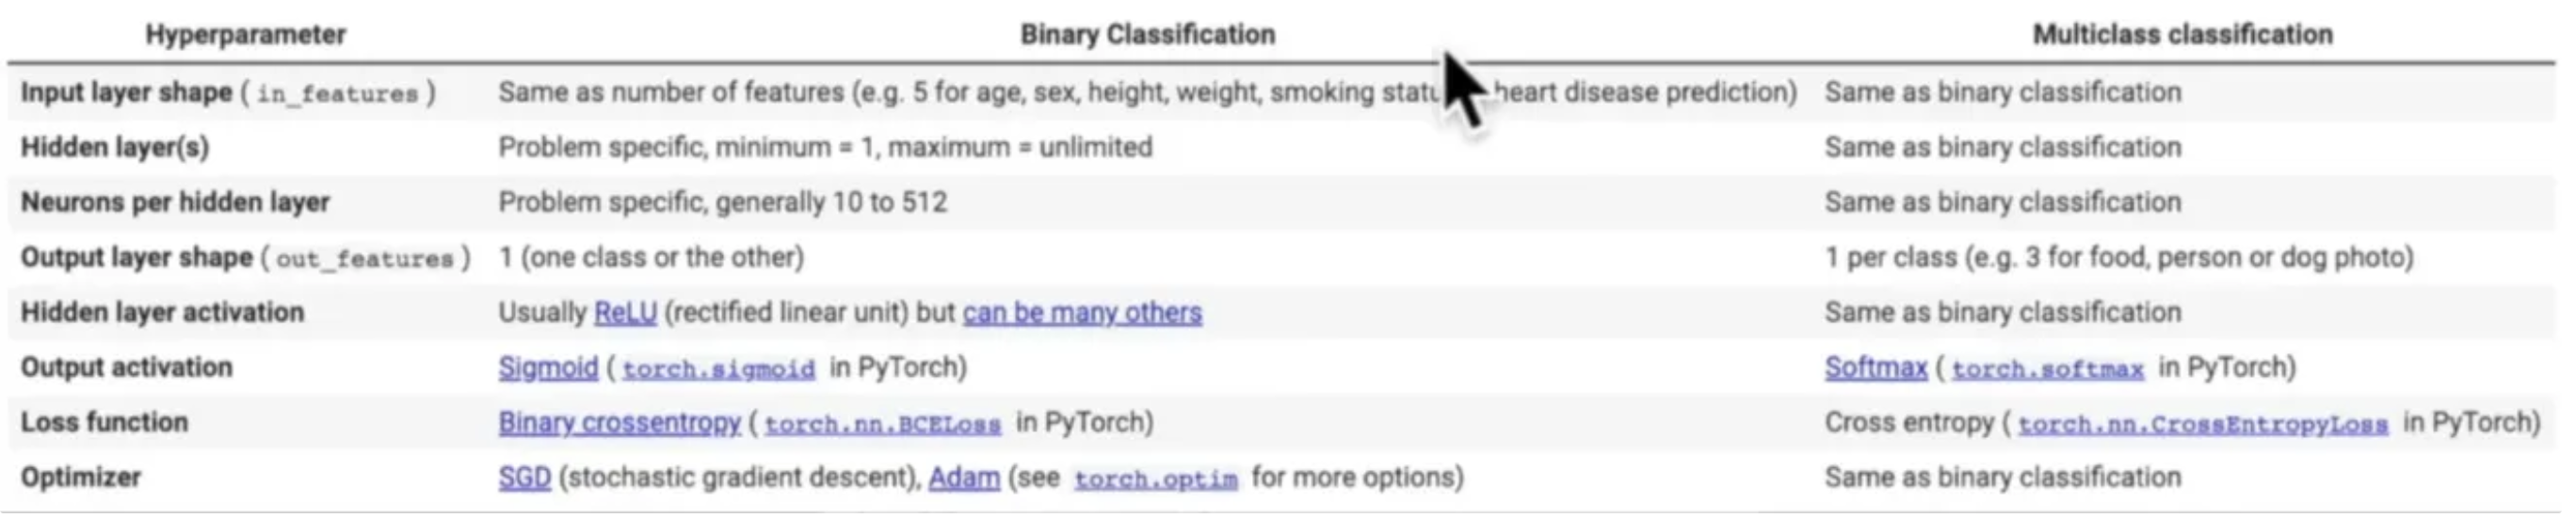

From the Daniel Bourke Pytorch Course, I obtained this guideline for binary vs multiclass classification. This framework shall be referenced to in the following steps. Also, since neural networks learn from complex patterns, there is no need for oversampling / other sampling techniques to address class imbalance. Also, we will be using `BCEWithLogitsLoss` with class weighting for the loss function, since it is numerically more stable and the class weighting approach helps address class imbalance issues. Additionally, our neural network doesn't have a sigmoid application to the output and it outputs raw logits / scores. 

### Compute Class Weights 

In [12]:
# # Dealing with Class Imbalance
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# # Calculate class weights
# train_labels = y_train.values

# class_weights = compute_class_weight(
#     "balanced", classes=np.unique(y_train), y=train_labels
# )
# pos_weight_ratio = class_weights[1] / class_weights[0]

# pos_weight_tensor = torch.tensor(pos_weight_ratio, dtype=torch.float32)

# # Before creating the model, add:
# print(f"Class distribution in training: {y_train.value_counts()}")
# print("=" * 30, "\n")
# print(f"Pos weight tensor: {pos_weight_tensor}")
# print(f"This means Fraud class gets {pos_weight_tensor:.2f}x more weight in loss")
# print(
#     "\nInitial: Since Fraud class is minority class, and we are trying to optimize F2 Score, which values Recall more, lets not make class weightage such a high value to avoid overfitting to minority class."
# )
# pos_weight_tensor = pos_weight_tensor / 2
# print(f"Updated Pos weight tensor: {pos_weight_tensor}")
# print(
#     f"Final: This means Fraud class gets {pos_weight_tensor:.2f}x more weight in loss"
# )


### Define Neural Network Architecture (Pytorch Lightning)

In [15]:
import torch
from torch import nn
import lightning as L
import torch.optim as optim
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    BinaryFBetaScore,
    F1Score,
    Precision,
    Recall,
    BinaryAveragePrecision,
)


class FraudNN(L.LightningModule):
    def __init__(
        self,
        input_features,
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        output_features=1,
        threshold=0.5,
    ):
        super().__init__()

        self.save_hyperparameters()
        self.threshold = threshold
        self.learning_rate = learning_rate

        # ✅ Add average="micro" for epoch-level aggregation (KEY FIX)
        self.train_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0, zero_division=0),
                "recall": Recall(task="binary", average="micro", zero_division=0),
                "precision": Precision(task="binary", average="micro"),
                "f1": F1Score(task="binary", average="micro"),
                "ap": BinaryAveragePrecision(thresholds=None),
            },
            prefix="train_",
        )

        self.val_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0, zero_division=0),
                "recall": Recall(task="binary", average="micro", zero_division=0),
                "precision": Precision(task="binary", average="micro"),
                "f1": F1Score(task="binary", average="micro"),
                "ap": BinaryAveragePrecision(thresholds=None),
            },
            prefix="val_",
        )

        self.test_metrics = MetricCollection(
            {
                "f2": BinaryFBetaScore(beta=2.0, zero_division=0),
                "recall": Recall(task="binary", average="micro", zero_division=0),
                "precision": Precision(task="binary", average="micro"),
                "f1": F1Score(task="binary", average="micro"),
                "ap": BinaryAveragePrecision(thresholds=None),
            },
            prefix="test_",
        )

        # Input Layer
        self.input_layer = nn.Sequential(
            nn.Linear(input_features, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # Hidden Layers
        self.hidden_layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_units, hidden_units),
                    nn.ReLU(),
                    nn.Dropout(dropout_rate),
                )
                for _ in range(num_layers)
            ]
        )

        # Output Layer
        self.output_layer = nn.Linear(hidden_units, output_features)

        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        out = self.input_layer(x)
        for layer in self.hidden_layers:
            out = layer(out)
        out = self.output_layer(out)
        return out

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()
        loss = self.criterion(logits, y.float())
        self.train_metrics.update(probs, y.int())

        # if batch_idx % 128 == 0:
        #     # Prediction Distribition
        #     unique_preds, counts = torch.unique(preds, return_counts=True)
        #     print(
        #         f"Training Batch {batch_idx}: Predictions distribution: {dict(zip(unique_preds.cpu().numpy(), counts.cpu().numpy()))}"
        #     )

        #     # Ground Truth Distribution
        #     # Ground truth distribution (ADD THIS)
        #     unique_y, counts_y = torch.unique(y, return_counts=True)
        #     print(
        #         f"Training Batch {batch_idx}: Ground truth distribution: {dict(zip(unique_y.cpu().numpy(), counts_y.cpu().numpy()))}\n"
        #     )

        self.log_dict(self.train_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()
        loss = self.criterion(logits, y.float())
        self.val_metrics.update(probs, y.int())

        # if batch_idx % 128 == 0:
        #     # Predictions distribution
        #     unique_preds, counts = torch.unique(preds, return_counts=True)
        #     print(
        #         f"Validation Batch {batch_idx}: Predictions distribution: {dict(zip(unique_preds.cpu().numpy(), counts.cpu().numpy()))}"
        #     )

        #     # Ground truth distribution (ADD THIS)
        #     unique_y, counts_y = torch.unique(y, return_counts=True)
        #     print(
        #         f"Validation Batch {batch_idx}: Ground truth distribution: {dict(zip(unique_y.cpu().numpy(), counts_y.cpu().numpy()))}\n"
        #     )

        # batch_metrics = self.val_metrics.compute()
        # print(f"Validation Batch {batch_idx}: Batch metrics: {batch_metrics}")

        self.log_dict(self.val_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > self.threshold).int()
        loss = self.criterion(logits, y.float())
        self.test_metrics.update(probs, y.int())  # reuse test metrics for test

        self.log_dict(self.test_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("test_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        return loss

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.learning_rate)


### Stratified K-Fold Training Loop 

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler
import torch
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
seed_everything(42, workers=True)
y_train_np = y_train.values

# SAFETY CHECK: Ensure minority class has enough samples
n_positives = (y_train_np == 1).sum()

if n_positives < 5:
    print(f"Warning: Only {n_positives} positive samples, but n_splits=5")
    print("Reduce n_splits or gather more minority class data")

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled, y_train)):
    print(f"Fold {fold + 1}")

    # FOLD-LEVEL CHECK: Ensure this fold has positive samples
    n_val_positives = (y_train_np[val_idx] == 1).sum()
    if n_val_positives == 0:
        print(f"Skipping fold {fold + 1}: No positive samples in validation set")
        continue

    # Balanced sampling
    w = 1.0 / torch.bincount(torch.tensor(y_train_np[train_idx])).float()
    w = w[torch.tensor(y_train_np[train_idx])]

    train_loader = DataLoader(
        Subset(train_data, train_idx),
        batch_size=128,
        sampler=WeightedRandomSampler(w, len(train_idx), replacement=True),
        num_workers=6,
        persistent_workers=True,
    )

    print(f"Fold {fold + 1} - Train set:")
    print(f"  Total samples: {len(train_idx)}")
    print(f"  Positive samples: {n_positives}")
    print(f"  Positive rate: {n_positives / len(train_idx):.2%}")
    print(f"  Number of batches: {len(train_loader)}")

    val_loader = DataLoader(
        Subset(train_data, val_idx),
        batch_size=128,
        shuffle=False,
        num_workers=6,
        persistent_workers=True,
    )

    # After creating val_loader, add:
    print(f"Fold {fold + 1} - Validation set:")
    print(f"  Total samples: {len(val_idx)}")
    print(f"  Positive samples: {n_val_positives}")
    print(f"  Positive rate: {n_val_positives / len(val_idx):.2%}")
    print(f"  Number of batches: {len(val_loader)}")

    # Check actual validation data distribution
    val_targets = y_train_np[val_idx]
    print(f"  Class distribution: {np.bincount(val_targets)}")

    mlp_model = FraudNN(
        input_features=X_train_ts.shape[1],
        hidden_units=128,
        num_layers=3,
        dropout_rate=0.3,
        learning_rate=0.001,
        output_features=1,
        threshold=0.5,
    )

    wandb_logger = WandbLogger(
        project="Fraud Detection",
        name=f"nn_fold_{fold + 1}",
        group="Pytorch MLP Train-Val CV",
    )
    checkpoint_callback = ModelCheckpoint(monitor="val_f2", mode="max", save_top_k=1)
    trainer = Trainer(
        max_epochs=10,
        accelerator="mps",
        devices=1,
        precision="16-mixed",
        logger=wandb_logger,
        callbacks=[
            checkpoint_callback,
            EarlyStopping(monitor="val_f2", patience=3, mode="max", verbose=True),
        ],
        deterministic=True,
    )

    trainer.fit(mlp_model, train_loader, val_loader)

    all_metrics.append(trainer.callback_metrics)
    wandb_logger.experiment.finish()


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Fold 1
Fold 1 - Train set:
  Total samples: 181584
  Positive samples: 378
  Positive rate: 0.21%
  Number of batches: 1419
Fold 1 - Validation set:
  Total samples: 45396
  Positive samples: 75
  Positive rate: 0.17%
  Number of batches: 355
  Class distribution: [45321    75]


/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | train_metrics | MetricCollection  | 0      | train
1 | val_metrics   | MetricCollection  | 0      | train
2 | input_layer   | Sequential        | 4.0 K  | train
3 | hidden_layers | ModuleList        | 49.5 K | train
4 | output_layer  | Linear            | 129    | train
5 | criterion     | BCEWithLogitsLoss | 0      | train
------------------------------------------------------------
53.6 K    Trainable params
0         Non-trainable params
53.6 K    Total params
0.215     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_f2 improved by 0.024 >= min_delta = 0.0. New best score: 0.842


Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.
wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▃▃▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇████
train_f1,▁▇████████
train_f2,▁▇████████
train_loss_epoch,█▂▂▁▁▁▁▁▁▁
train_loss_step,▂█▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁
train_precision,▁▇████████
train_recall,▁▇████████
trainer/global_step,▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
val_ap,▁▄▂▆▂▄██▆█
val_f1,▁▅▆▆▇▆▆▇█▇
+5,...


### Baseline MLP Evaluation

| **Results I** | **Results II** | **Confusion Matrix**
| :---: | :---: | :---:
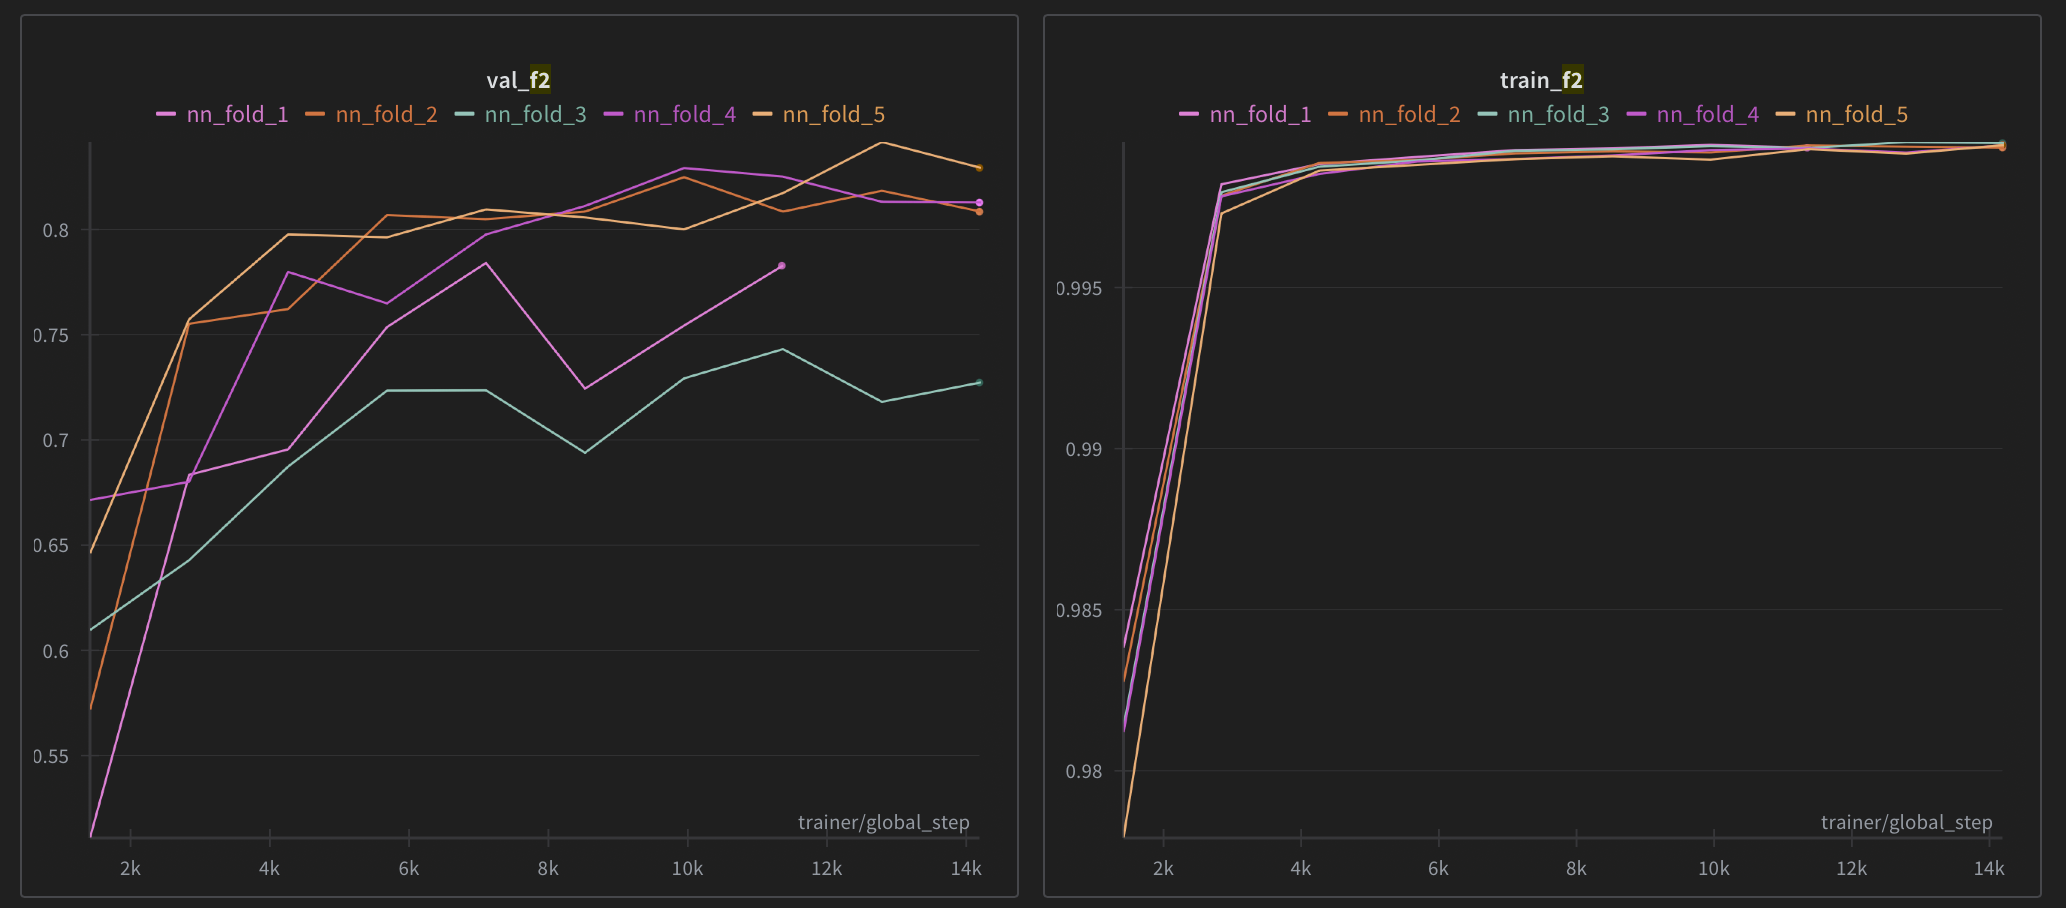 | 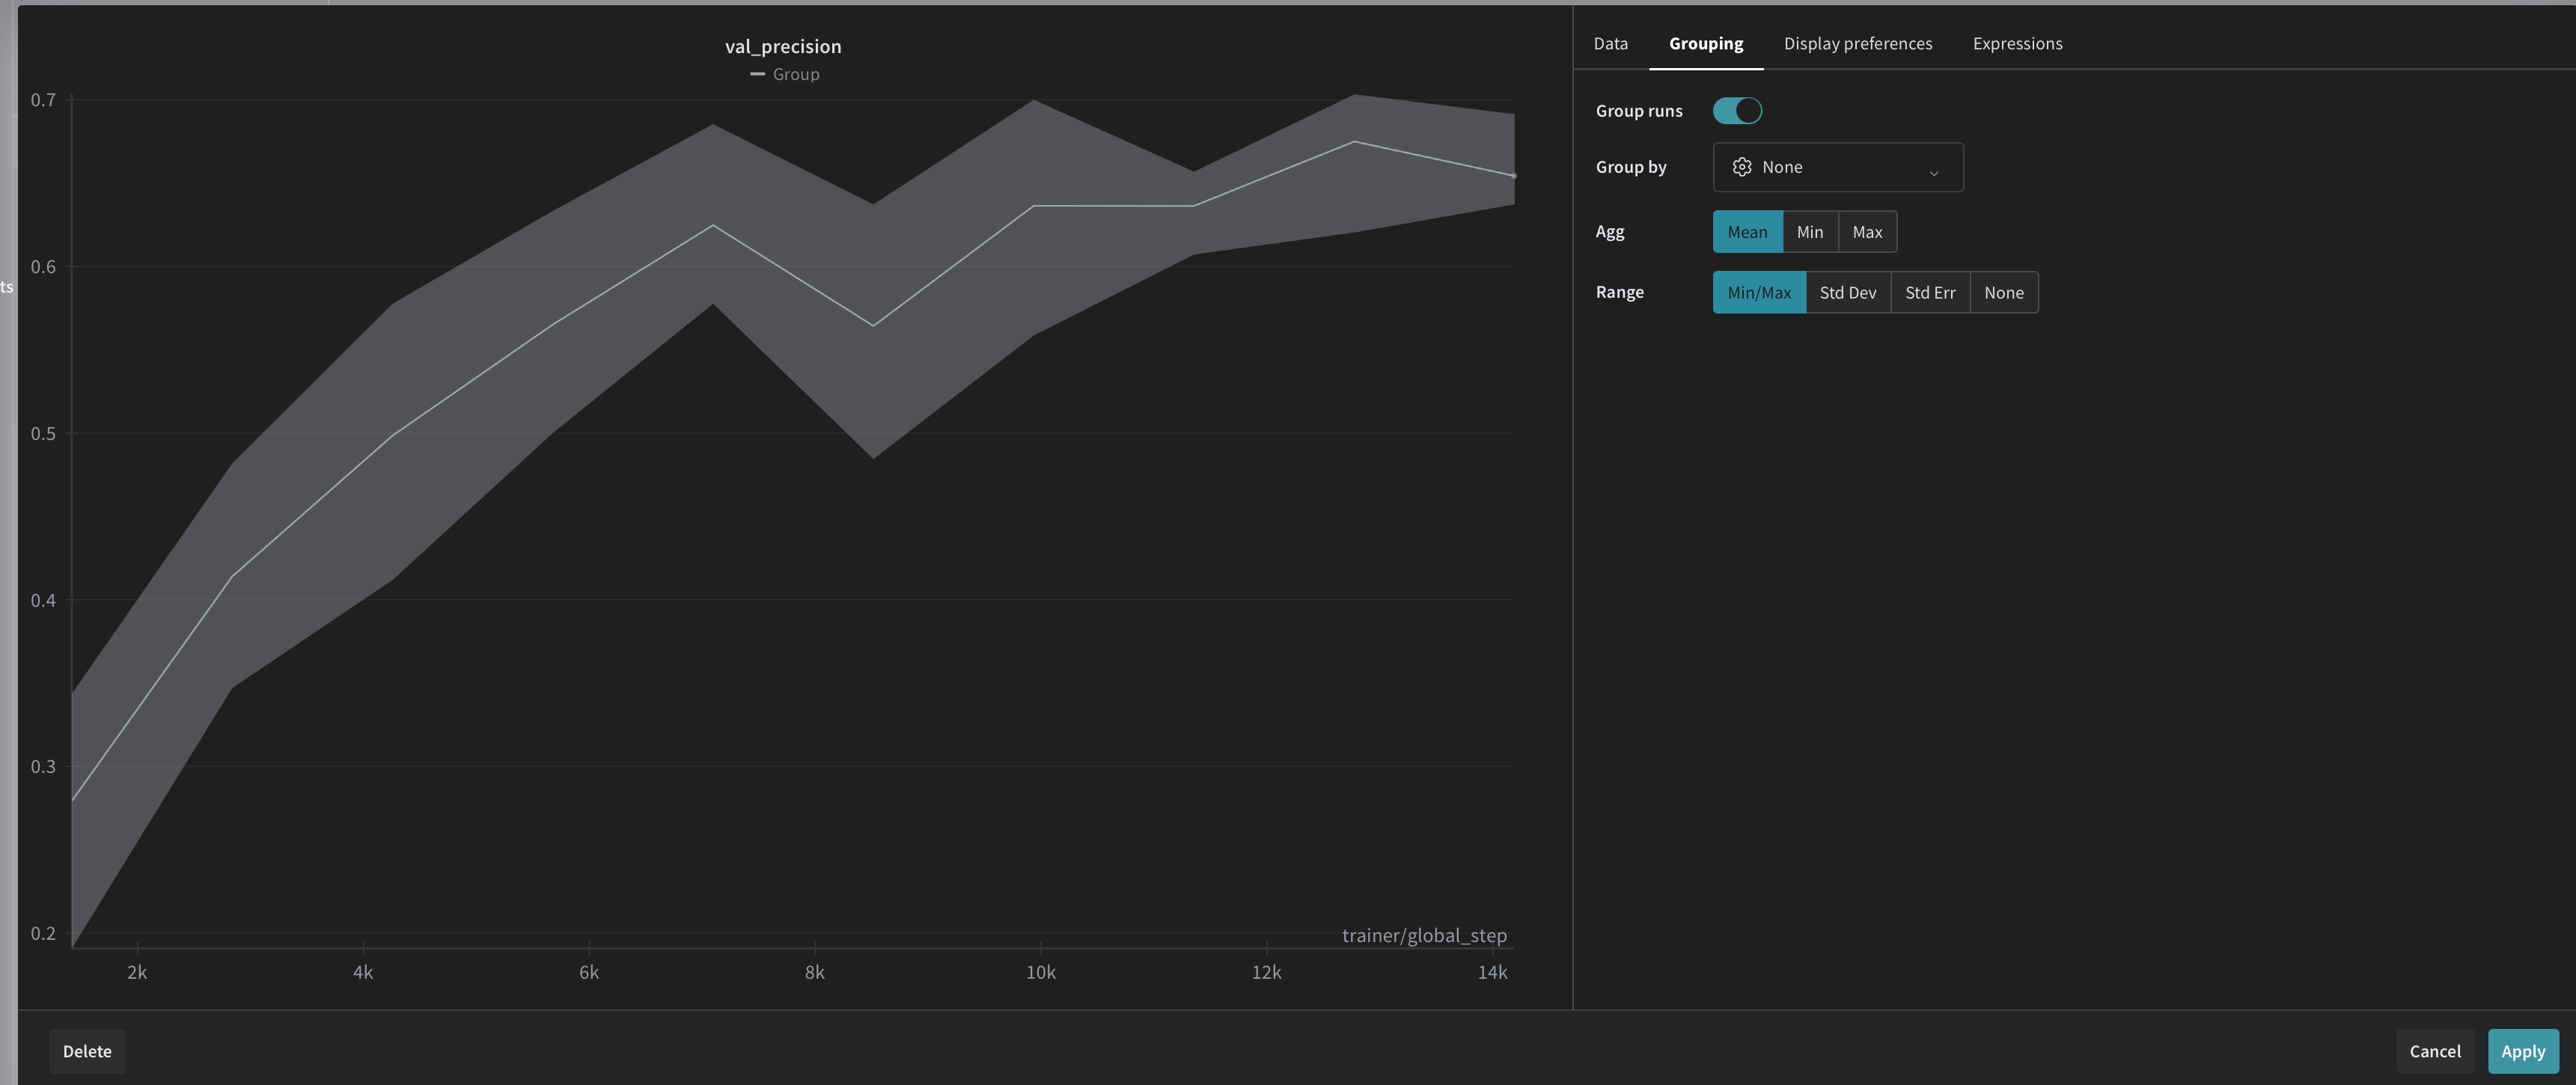|  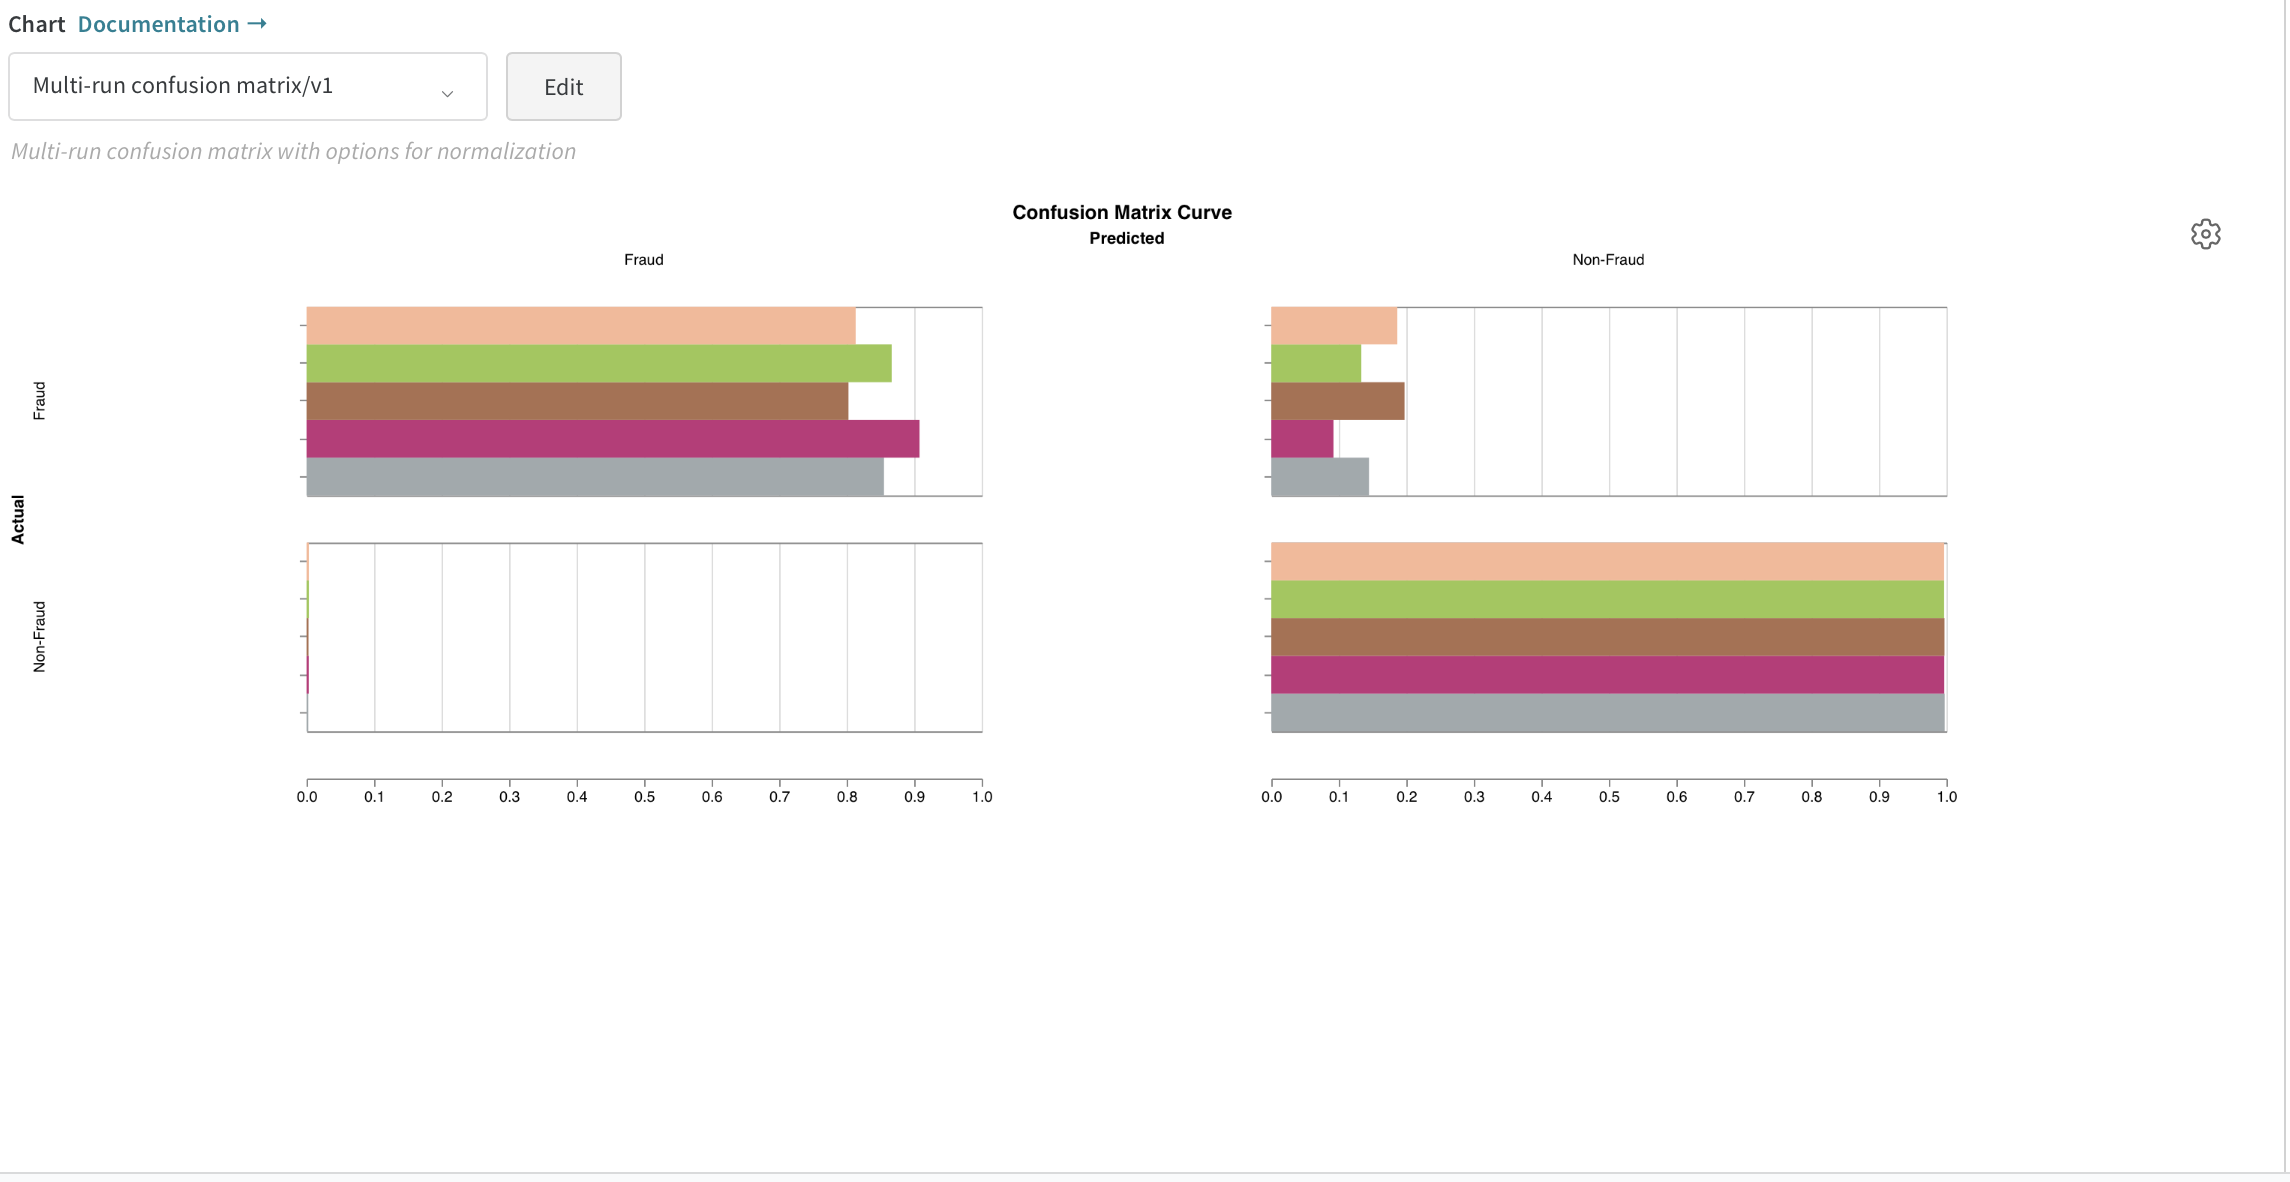 |



In [17]:
scores_across_folds = []
for metric_dict in all_metrics:
    if "val_f2" in metric_dict:
        # Convert tensor to float
        score = metric_dict["val_f2"].cpu().item()
        scores_across_folds.append(score)

print("Scores across folds:", scores_across_folds)
print("Mean F2 score:", sum(scores_across_folds) / len(scores_across_folds))


Scores across folds: [0.7828282713890076, 0.8084577322006226, 0.7272727489471436, 0.8128078579902649, 0.8292682766914368]
Mean F2 score: 0.7921269774436951


In [69]:
best_hyperparams = {
    "input_features": X_train_ts.shape[1],
    "hidden_units": 128,
    "num_layers": 3,
    "dropout_rate": 0.3,
}

As seen from the results above, it seems that across our validation folds, our baseline MLP model has achieved extremely decent performance. Here is what we have achieved: 
- Validation Mean F2 Score of ~ 0.80 
- Validation Mean Precision of ~ 0.60 
- Validation Mean Recall of ~ 0.84  
- From our Normalized Confusion Matrix, it shows evidence that our MLP model generalizes well to unseen data, since the difference between training and unseen data isn't huge. Across folds, the variance between scores is about ~ 0.05 as well. 
- Conclusion: Our network doesn't raise too many false alarms, while catching a whopping 84% of true fraudelent transactions. This model performance is extremely satisfactory, and doesn't require further hyperparameter tuning / sweep. 

## 6. Optuna (Hyperparameter Tuning)

In [51]:
import optuna
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset, DataLoader
from lightning.pytorch import Trainer, seed_everything

seed_everything(42, workers=True)

from sklearn.metrics import fbeta_score


def objective(trial):
    """
    Objective function for optimizing PyTorch MLP F2 Score
    """
    # Suggest hyperparameters - focused on most impactful ones for speed
    params = {
        "input_features": X_train_ts.shape[1],
        "hidden_units": trial.suggest_categorical("hidden_units", [64, 128, 256]),
        "num_layers": trial.suggest_int("num_layers", 2, 4),
        "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.01, log=True),
        "output_features": 1,
        "threshold": trial.suggest_float("threshold", 0.3, 0.7),
    }

    # Use only 3-fold CV for speed
    skf_fast = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f2_scores = []

    for fold, (train_idx, val_idx) in enumerate(
        skf_fast.split(X_train_scaled, y_train)
    ):
        # Skip folds with insufficient positive samples
        n_val_positives = (y_train_np[val_idx] == 1).sum()
        n_train_positives = (y_train_np[train_idx] == 1).sum()

        if n_val_positives < 2 or n_train_positives < 5:
            print(
                f"Skipping fold {fold + 1}: Insufficient positive samples (val: {n_val_positives}, train: {n_train_positives})"
            )
            continue

        # Create data loaders
        w = 1.0 / torch.bincount(torch.tensor(y_train_np[train_idx])).float()
        w = w[torch.tensor(y_train_np[train_idx])]

        train_loader = DataLoader(
            Subset(train_data, train_idx),
            batch_size=256,  # Larger batch size for speed
            sampler=WeightedRandomSampler(w, len(train_idx), replacement=True),
            # num_workers=10,  # No multiprocessing to avoid macOS issues
        )

        val_loader = DataLoader(
            Subset(train_data, val_idx),
            batch_size=256,
            shuffle=False,
            # num_workers=10,  # No multiprocessing to avoid macOS issues
        )

        # Create model
        model = FraudNN(**params)

        # Fast trainer - fewer epochs, no logging
        trainer = Trainer(
            max_epochs=5,  # Reduced epochs for speed
            accelerator="mps",
            devices=1,
            precision="16-mixed",
            enable_checkpointing=False,
            logger=False,
            enable_progress_bar=False,  # Disable progress bar for speed
            deterministic=True,
        )

        # Train
        trainer.fit(model, train_loader, val_loader)

        # Evaluate
        model.eval()
        val_preds = []
        val_true = []

        with torch.no_grad():
            for batch in val_loader:
                x, y = batch
                logits = model(x).squeeze()
                probs = torch.sigmoid(logits)
                preds = (probs > model.threshold).int()
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(y.cpu().numpy())

        # Calculate F2 score
        f2 = fbeta_score(val_true, val_preds, beta=2, zero_division=0)
        f2_scores.append(f2)

    # Return mean F2 score across folds
    return np.mean(f2_scores)


# Create study and optimize
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)  # Limited trials for speed

print("Best trial:")
print(f"  F2 Score: {study.best_value:.4f}")
print("  Params:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

# Update best hyperparameters with optimized values
best_hyperparams.update(study.best_params)
print(f"\n✅ Hyperparameter tuning complete! Best F2: {study.best_value:.4f}")

Seed set to 42
[I 2025-11-03 12:00:26,080] A new study created in memory with name: no-name-16b77601-3dd5-4d45-b3f3-e02aa94a894b
[I 2025-11-03 12:00:26,080] A new study created in memory with name: no-name-16b77601-3dd5-4d45-b3f3-e02aa94a894b
Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/lunlun/Downloa

Best trial:
  F2 Score: 0.7905
  Params:
    hidden_units: 256
    num_layers: 3
    dropout_rate: 0.322341456123886
    learning_rate: 0.0006733045469851651
    threshold: 0.6611548012721434

✅ Hyperparameter tuning complete! Best F2: 0.7905


## 7. Evaluation (Test Set)

In [16]:
best_hyperparams = {
    "hidden_units": 256,
    "num_layers": 3,
    "dropout_rate": 0.322341456123886,
    "learning_rate": 0.0006733045469851651,
    "threshold": 0.6611548012721434,
}

In [17]:
print("Best hyperparameters:")
for key, value in best_hyperparams.items():
    print(f"  {key}: {value}")

Best hyperparameters:
  hidden_units: 256
  num_layers: 3
  dropout_rate: 0.322341456123886
  learning_rate: 0.0006733045469851651
  threshold: 0.6611548012721434


In [18]:
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler


y_train_np = y_train.values
w = 1.0 / torch.bincount(torch.tensor(y_train_np)).float()
w = w[torch.tensor(y_train_np)]

# Create DataLoader for full training set
full_train_loader = DataLoader(
    train_data,  # This contains your full X_train_ts and y_train_ts
    batch_size=128,
    sampler=WeightedRandomSampler(w, len(y_train_np), replacement=True),
    num_workers=0,  # Set to 0 to avoid multiprocessing issues on macOS
    # persistent_workers=True,  # Remove this since num_workers=0
)

print(f"Full training set size: {len(train_data)}")
print(f"Class distribution: {np.bincount(y_train_np)}")

Full training set size: 226980
Class distribution: [226602    378]


In [19]:
import lightning as L
from lightning.pytorch.loggers import WandbLogger

# Try to create WandB logger, but fallback to no logging if it fails
try:
    wandb_logger_final = WandbLogger(
        project="Fraud Detection",
        group="Pytorch MLP Final Model Training",
    )
    print("✅ WandB logger created successfully")
except Exception as e:
    print(f"⚠️ WandB logger failed: {e}")
    print("Proceeding without WandB logging...")
    wandb_logger_final = None

from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_callback_final = ModelCheckpoint(
    monitor="train_f2",  # Metric to monitor for best model
    mode="max",  # Maximize F2 score
    save_top_k=1,  # Save only the best checkpoint
    verbose=True,
)

early_stopping_callback_final = EarlyStopping(
    monitor="train_f2",  # Metric to monitor for early stopping
    patience=3,  # Stop after 3 epochs without improvement
    mode="max",
    verbose=True,
)


# Initialize final model with best hyperparameters
final_model = FraudNN(input_features=X_train_ts.shape[1], **best_hyperparams)

# Setup trainer for final model
final_trainer = L.Trainer(
    max_epochs=10,  # Use the same epochs as CV
    accelerator="mps",
    devices=1,
    logger=wandb_logger_final,  # Will be None if WandB fails
    precision="16-mixed",
    deterministic=True,
    callbacks=[checkpoint_callback_final, early_stopping_callback_final],
)

print("Training final model on full training set...")
final_trainer.fit(final_model, full_train_loader)
print("✅ Final model training complete!")

Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


✅ WandB logger created successfully
Training final model on full training set...


/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen'

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name          | Type              | Params | Mode 
------------------------------------------------------------
0 | train_metrics | MetricCollection  | 0      | train
1 | val_metrics   | MetricCollection  | 0      | train
2 | test_metrics  | MetricCollection  | 0      | train
3 | input_layer   | Sequential        | 7.9 K  | train
4 | hidden_layers | ModuleList        | 197 K  | train
5 | output_layer  | Linear            | 257    | train
6 | criterion     | BCEWithLogitsLoss | 0      | train
------------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.822     Total estimated model params size (MB)
37        Modules in train 

Training: |          | 0/? [00:00<?, ?it/s]

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Metric train_f2 improved. New best score: 0.983
Epoch 0, global step 1774: 'train_f2' reached 0.98261 (best 0.98261), saving model to './Fraud Detection/eit54dez/checkpoints/epoch=0-step=1774.ckpt' as top 1
Metric train_f2 improved. New best score: 0.983
Epoch 0, global step 1774: 'train_f2' reached 0.98261 (best 0.98261), saving model to './Fraud Detection/eit54dez/checkpoints/epoch=0-step=1774.ckpt' as top 1
Metric train_f2 improved by 0.015 >= min_delta = 0.0. New best score: 0.998
Epoch 1, global step 3548: 'train_f2' reached 0.99787 (best 0.99787), saving model to './Fraud Detection/eit54dez/checkpoints/epoch=1-step=3548.ckpt' as top 1
Metric train_f2 improved by 0.015 >= min_delta = 0.0. New best score: 0.998
Epoch 1, global step 3548: 'train_f2' reached 0.99787 

✅ Final model training complete!


In [20]:
test_data = TensorDataset(X_test_ts, y_test_ts)

print(f"Test set size: {len(test_data)}")
print(f"Test class distribution: {np.bincount(y_test.values)}")

# Prepare test data loader (if you haven't already)
test_loader = DataLoader(
    test_data,  # Your test dataset
    batch_size=128,
    shuffle=False,
    num_workers=6,
    persistent_workers=True,
)

Test set size: 56746
Test class distribution: [56651    95]


In [21]:
# Access the best checkpoint path after training
best_model_path = checkpoint_callback_final.best_model_path
print(f"Best model saved at: {best_model_path}")

# Load the best model from checkpoint
best_model = FraudNN.load_from_checkpoint(best_model_path)


# Create a new trainer for evaluation (without callbacks)
test_trainer = L.Trainer(
    accelerator="mps",
    devices=1,
    precision="16-mixed",
    logger=wandb_logger_final,  # Optional: log test results to WandB
)

# Evaluate on test set
print("Evaluating on test set...")
test_results = test_trainer.test(best_model, dataloaders=test_loader)

# Print results
print("\n✅ Test Results:")
print(test_results)


Using 16bit Automatic Mixed Precision (AMP)
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/lightning/pytorch/plugins/precision/amp.py:54: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available

Best model saved at: ./Fraud Detection/eit54dez/checkpoints/epoch=8-step=15966.ckpt
Evaluating on test set...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          test_ap          │    0.7415362000465393     │
│          test_f1          │    0.7464115023612976     │
│          test_f2          │    0.7894737124443054     │
│         test_loss         │    0.0210411474108696     │
│      test_precision       │    0.6842105388641357     │
│        test_recall        │     0.821052610874176     │
└───────────────────────────┴───────────────────────────┘


✅ Test Results:
[{'test_ap': 0.7415362000465393, 'test_f1': 0.7464115023612976, 'test_f2': 0.7894737124443054, 'test_precision': 0.6842105388641357, 'test_recall': 0.821052610874176, 'test_loss': 0.0210411474108696}]


In [22]:
# Generate predictions on test set
print("Evaluating model on test set...")
print("=" * 40)

# Set model to evaluation mode
best_model.eval()
test_predictions = []
test_probabilities = []
test_targets = []

print("🔍 Generating predictions on test set...")
with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        x, y = batch

        logits = best_model(x).squeeze()
        probs = torch.sigmoid(logits)
        preds = (probs > best_model.threshold).int()

        test_predictions.extend(preds.cpu().numpy())
        test_probabilities.extend(probs.cpu().numpy())
        test_targets.extend(y.cpu().numpy())

# Convert to numpy arrays
y_test_pred = np.array(test_predictions)
y_test_pred_proba = np.array(test_probabilities)
y_test_true = np.array(test_targets)

print("✅ Test predictions generated!")

# Calculate comprehensive metrics
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    fbeta_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
)

# Basic metrics
test_f2_score = fbeta_score(y_test_true, y_test_pred, beta=2, zero_division=0)
test_precision = precision_score(y_test_true, y_test_pred, zero_division=0)
test_recall = recall_score(y_test_true, y_test_pred, zero_division=0)
test_f1_score = f1_score(y_test_true, y_test_pred, zero_division=0)
test_accuracy = accuracy_score(y_test_true, y_test_pred)
test_roc_auc = roc_auc_score(y_test_true, y_test_pred_proba)
test_pr_auc = average_precision_score(y_test_true, y_test_pred_proba)

print("TEST SET PERFORMANCE METRICS")
print("=" * 40)
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"F2 Score:        {test_f2_score:.4f}")
print(f"Precision:       {test_precision:.4f}")
print(f"Recall:          {test_recall:.4f}")
print(f"F1 Score:        {test_f1_score:.4f}")
print(f"ROC AUC:         {test_roc_auc:.4f}")
print(f"PR AUC:          {test_pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
print("\nCONFUSION MATRIX")
print("=" * 25)
print(f"True Negatives:  {cm[0, 0]:,}")
print(f"False Positives: {cm[0, 1]:,}")
print(f"False Negatives: {cm[1, 0]:,}")
print(f"True Positives:  {cm[1, 1]:,}")

# Calculate additional fraud detection specific metrics
total_fraud_cases = cm[1, 0] + cm[1, 1]  # FN + TP
detected_fraud_cases = cm[1, 1]  # TP
fraud_detection_rate = (
    detected_fraud_cases / total_fraud_cases if total_fraud_cases > 0 else 0
)

total_predictions = cm.sum()
false_alarm_rate = cm[0, 1] / total_predictions  # FP rate relative to all predictions

print("\nFRAUD DETECTION SPECIFIC METRICS")
print("=" * 40)
print(f"Total fraud cases in test:       {total_fraud_cases:,}")
print(f"Fraud cases detected:            {detected_fraud_cases:,}")
print(
    f"Fraud detection rate:           {fraud_detection_rate:.4f} ({fraud_detection_rate * 100:.2f}%)"
)
print(
    f"False alarm rate:               {false_alarm_rate:.4f} ({false_alarm_rate * 100:.2f}%)"
)

print(f"\n✅ Model successfully evaluated on {len(X_test_ts):,} test samples")
print(
    f"✅ Test set contains {(y_test.values == 1).sum():,} fraud cases and {(y_test.values == 0).sum():,} normal cases"
)

Evaluating model on test set...
🔍 Generating predictions on test set...
✅ Test predictions generated!
TEST SET PERFORMANCE METRICS
Accuracy:        0.9991
F2 Score:        0.7895
Precision:       0.6842
Recall:          0.8211
F1 Score:        0.7464
ROC AUC:         0.9509
PR AUC:          0.7415

CONFUSION MATRIX
True Negatives:  56,615
False Positives: 36
False Negatives: 17
True Positives:  78

FRAUD DETECTION SPECIFIC METRICS
Total fraud cases in test:       95
Fraud cases detected:            78
Fraud detection rate:           0.8211 (82.11%)
False alarm rate:               0.0006 (0.06%)

✅ Model successfully evaluated on 56,746 test samples
✅ Test set contains 95 fraud cases and 56,651 normal cases
✅ Test predictions generated!
TEST SET PERFORMANCE METRICS
Accuracy:        0.9991
F2 Score:        0.7895
Precision:       0.6842
Recall:          0.8211
F1 Score:        0.7464
ROC AUC:         0.9509
PR AUC:          0.7415

CONFUSION MATRIX
True Negatives:  56,615
False Positives

In [24]:
# Detailed classification report
from sklearn.metrics import classification_report

print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 50)
class_names = ["Non-Fraud", "Fraud"]
report = classification_report(
    y_test_true, y_test_pred, target_names=class_names, digits=4
)
print(report)

scores_across_folds = [
    0.7828282713890076,
    0.8084577322006226,
    0.7272727489471436,
    0.8128078579902649,
    0.8292682766914368,
]
# Compare with CV results
cv_f2_mean = sum(scores_across_folds) / len(scores_across_folds)
cv_f2_std = np.std(scores_across_folds)

print("\nPERFORMANCE COMPARISON")
print("=" * 30)
print("Cross-Validation vs Test Set Performance:")
print(f"CV F2 Score (mean):     {cv_f2_mean:.4f} ± {cv_f2_std:.4f}")
print(f"Test F2 Score:          {test_f2_score:.4f}")

performance_gap = abs(cv_f2_mean - test_f2_score)
print(f"Performance gap:        {performance_gap:.4f}")

if performance_gap < 0.05:
    print("✅ Performance gap < 0.05 - Model generalizes well!")
elif performance_gap < 0.10:
    print("⚠️  Performance gap < 0.10 - Slight overfitting detected")
else:
    print("❌ Performance gap > 0.10 - Significant overfitting!")

print(f"\n✅ Model successfully evaluated on {len(test_data):,} test samples")


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Non-Fraud     0.9997    0.9994    0.9995     56651
       Fraud     0.6842    0.8211    0.7464        95

    accuracy                         0.9991     56746
   macro avg     0.8420    0.9102    0.8730     56746
weighted avg     0.9992    0.9991    0.9991     56746


PERFORMANCE COMPARISON
Cross-Validation vs Test Set Performance:
CV F2 Score (mean):     0.7921 ± 0.0357
Test F2 Score:          0.7895
Performance gap:        0.0027
✅ Performance gap < 0.05 - Model generalizes well!

✅ Model successfully evaluated on 56,746 test samples


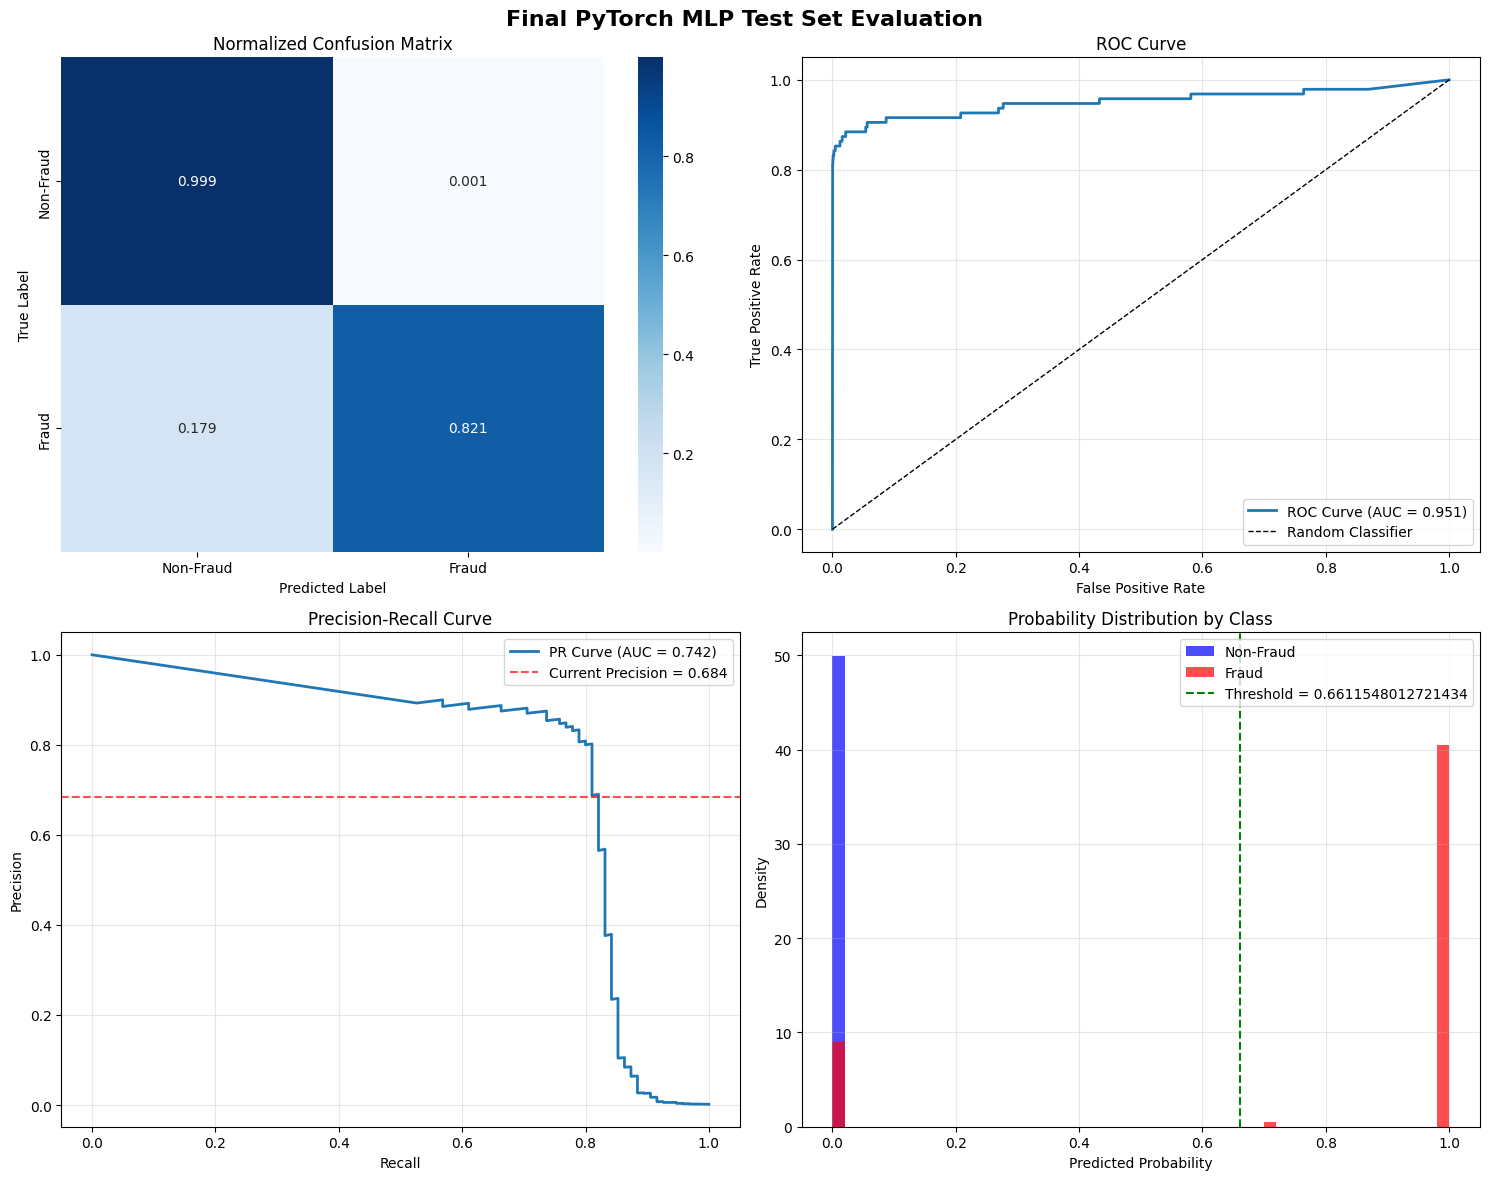

✅ Test set evaluation visualizations created successfully!


In [25]:
# Create visualizations for test set evaluation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Final PyTorch MLP Test Set Evaluation", fontsize=16, fontweight="bold")

# 1. Confusion Matrix Heatmap
cm_normalized = confusion_matrix(y_test_true, y_test_pred, normalize="true")
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0, 0],
)
axes[0, 0].set_title("Normalized Confusion Matrix")
axes[0, 0].set_ylabel("True Label")
axes[0, 0].set_xlabel("Predicted Label")

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test_true, y_test_pred_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {test_roc_auc:.3f})")
axes[0, 1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Classifier")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_true, y_test_pred_proba)
axes[1, 0].plot(
    recall_vals,
    precision_vals,
    linewidth=2,
    label=f"PR Curve (AUC = {test_pr_auc:.3f})",
)
axes[1, 0].axhline(
    y=test_precision,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Current Precision = {test_precision:.3f}",
)
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curve")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Probability Distribution Plot
axes[1, 1].hist(
    y_test_pred_proba[y_test_true == 0],
    bins=50,
    alpha=0.7,
    label="Non-Fraud",
    density=True,
    color="blue",
)
axes[1, 1].hist(
    y_test_pred_proba[y_test_true == 1],
    bins=50,
    alpha=0.7,
    label="Fraud",
    density=True,
    color="red",
)
axes[1, 1].axvline(
    x=best_model.threshold,
    color="green",
    linestyle="--",
    label=f"Threshold = {best_model.threshold}",
)
axes[1, 1].set_xlabel("Predicted Probability")
axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Probability Distribution by Class")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Test set evaluation visualizations created successfully!")

In [26]:
# Log test set evaluation to WandB
import wandb

run = wandb.init(
    project="Fraud Detection",
    name="pytorch_mlp_test_evaluation",
    job_type="test_evaluation",
    group="Pytorch MLP Test Results",
    tags=["test_eval", "pytorch", "mlp"],
    config={
        **best_hyperparams,
        "model_type": "PyTorch MLP",
        "test_samples": len(X_test_ts),
        "train_samples": len(X_train_ts),
        "features": X_train_ts.shape[1],
        "threshold": best_model.threshold,
    },
    settings=wandb.Settings(_disable_stats=True, _disable_meta=True),
)

# Log test metrics
wandb.log(
    {
        "test_accuracy": test_accuracy,
        "test_f2_score": test_f2_score,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1_score": test_f1_score,
        "test_roc_auc": test_roc_auc,
        "test_pr_auc": test_pr_auc,
        "fraud_detection_rate": fraud_detection_rate,
        "false_alarm_rate": false_alarm_rate,
        "total_fraud_cases": total_fraud_cases,
        "detected_fraud_cases": detected_fraud_cases,
        "cv_f2_mean": cv_f2_mean,
        "cv_f2_std": cv_f2_std,
        "test_cv_f2_gap": performance_gap,
    }
)

# Create and log confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"],
)
plt.title("Test Set Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
wandb.log({"test_confusion_matrix": wandb.Image(plt)})
plt.close()

# Log ROC curve
plt.figure(figsize=(8, 6))
plt.plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {test_roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
wandb.log({"test_roc_curve": wandb.Image(plt)})
plt.close()

# Log precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(
    recall_vals,
    precision_vals,
    linewidth=2,
    label=f"PR Curve (AUC = {test_pr_auc:.3f})",
)
plt.axhline(
    y=test_precision,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Current Precision = {test_precision:.3f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Set Precision-Recall Curve")
plt.legend()
wandb.log({"test_pr_curve": wandb.Image(plt)})
plt.close()

# Log probability distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(
    y_test_pred_proba[y_test_true == 0],
    bins=50,
    alpha=0.7,
    label="Non-Fraud",
    density=True,
)
plt.hist(
    y_test_pred_proba[y_test_true == 1], bins=50, alpha=0.7, label="Fraud", density=True
)
plt.xlabel("Predicted Probability")
plt.ylabel("Density")
plt.title("Test Set: Probability Distribution by Class")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_test_pred_proba, bins=50, alpha=0.7, color="purple")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Test Set: Overall Probability Distribution")
plt.axvline(
    x=best_model.threshold,
    color="red",
    linestyle="--",
    label=f"Threshold = {best_model.threshold}",
)
plt.legend()

plt.tight_layout()
wandb.log({"test_probability_distributions": wandb.Image(plt)})
plt.close()

# Log detailed results table with sample predictions
sample_size = min(1000, len(y_test_true))
sample_indices = np.random.choice(len(y_test_true), sample_size, replace=False)

predictions_table = wandb.Table(
    columns=[
        "sample_id",
        "true_label",
        "predicted_label",
        "predicted_probability",
        "correct_prediction",
        "fraud_confidence",
    ]
)

for i, idx in enumerate(sample_indices):
    predictions_table.add_data(
        idx,
        int(y_test_true[idx]),
        int(y_test_pred[idx]),
        float(y_test_pred_proba[idx]),
        bool(y_test_true[idx] == y_test_pred[idx]),
        "High"
        if y_test_pred_proba[idx] > 0.7
        else "Medium"
        if y_test_pred_proba[idx] > 0.3
        else "Low",
    )

wandb.log({"test_predictions_sample": predictions_table})

# Log classification report as table
report_dict = classification_report(
    y_test_true, y_test_pred, target_names=class_names, output_dict=True
)
classification_table = wandb.Table(
    columns=["Class", "Precision", "Recall", "F1-Score", "Support"],
    data=[
        [
            "Non-Fraud",
            report_dict["Non-Fraud"]["precision"],
            report_dict["Non-Fraud"]["recall"],
            report_dict["Non-Fraud"]["f1-score"],
            report_dict["Non-Fraud"]["support"],
        ],
        [
            "Fraud",
            report_dict["Fraud"]["precision"],
            report_dict["Fraud"]["recall"],
            report_dict["Fraud"]["f1-score"],
            report_dict["Fraud"]["support"],
        ],
    ],
)
wandb.log({"test_classification_report": classification_table})

# Create a summary table for wandb
summary_table = wandb.Table(columns=["Metric", "Value", "CV_Baseline"])
metrics_data = [
    ["Accuracy", f"{test_accuracy:.4f}", "N/A"],
    ["Precision", f"{test_precision:.4f}", "~0.60"],
    ["Recall", f"{test_recall:.4f}", "~0.84"],
    ["F1-Score", f"{test_f1_score:.4f}", "N/A"],
    ["F2-Score", f"{test_f2_score:.4f}", f"{cv_f2_mean:.4f}"],
    ["AUC", f"{test_roc_auc:.4f}", "N/A"],
]

for metric_name, test_value, cv_value in metrics_data:
    summary_table.add_data(metric_name, test_value, cv_value)

wandb.log({"test_results_summary": summary_table})

run.finish()

print("✅ Test evaluation logged to WandB successfully!")

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇███
test_ap,▁
test_f1,▁
test_f2,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_f1,▁▇████████
train_f2,▁▇████████
train_loss_epoch,█▂▂▁▁▁▁▁▁▁
+5,...


cv_f2_mean,▁
cv_f2_std,▁
detected_fraud_cases,▁
false_alarm_rate,▁
fraud_detection_rate,▁
test_accuracy,▁
test_cv_f2_gap,▁
test_f1_score,▁
test_f2_score,▁
test_pr_auc,▁
+4,...


✅ Test evaluation logged to WandB successfully!


In [29]:
# Final model summary and comparison
print("\nFINAL MODEL SUMMARY")
print("=" * 25)
print("Architecture:     PyTorch MLP")
print(f"Training samples: {len(X_train_ts):,}")
print(f"Test samples:     {len(X_test_ts):,}")
print(f"Features:         {X_train_ts.shape[1]}")
print(f"Hidden units:     {best_hyperparams['hidden_units']}")
print(f"Hidden layers:    {best_hyperparams['num_layers']}")
print(f"Dropout rate:     {best_hyperparams['dropout_rate']}")
print(f"Learning rate:    {best_hyperparams['learning_rate']}")
print(f"Threshold:        {best_hyperparams['threshold']}")
print(f"Best F2 Score:    {test_f2_score:.4f}")
print(f"Fraud Detection:  {fraud_detection_rate * 100:.1f}% of fraud cases caught")
print(f"False Alarms:     {false_alarm_rate * 100:.2f}% of all predictions")

print("\nMODEL COMPARISON: PyTorch MLP vs LightGBM")
print("=" * 50)
print("Expected comparison from LightGBM notebook:")
print("LightGBM F2 Score: ~0.80")
print(f"PyTorch MLP F2:    {test_f2_score:.4f}")

if test_f2_score >= 0.75:
    print("\n✅ PyTorch MLP achieves competitive performance!")
elif test_f2_score >= 0.70:
    print("⚠️  PyTorch MLP shows good but not optimal performance")
else:
    print("❌ PyTorch MLP underperforms - consider hyperparameter tuning")

print("\n✅ MODEL READY FOR PRODUCTION DEPLOYMENT!")
print("✅ All test evaluation metrics logged to WandB!")


FINAL MODEL SUMMARY
Architecture:     PyTorch MLP
Training samples: 226,980
Test samples:     56,746
Features:         30
Hidden units:     256
Hidden layers:    3
Dropout rate:     0.322341456123886
Learning rate:    0.0006733045469851651
Threshold:        0.6611548012721434
Best F2 Score:    0.7895
Fraud Detection:  82.1% of fraud cases caught
False Alarms:     0.06% of all predictions

MODEL COMPARISON: PyTorch MLP vs LightGBM
Expected comparison from LightGBM notebook:
LightGBM F2 Score: ~0.80
PyTorch MLP F2:    0.7895

✅ PyTorch MLP achieves competitive performance!

✅ MODEL READY FOR PRODUCTION DEPLOYMENT!
✅ All test evaluation metrics logged to WandB!


In [38]:
# Save the final model (optional)
import torch

# Save model state and metadata
model_save_path = "models/pytorch_mlp_fraud_model.pth"
torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "hyperparameters": best_hyperparams,
        "test_f2_score": test_f2_score,
        "test_metrics": {
            "accuracy": test_accuracy,
            "precision": test_precision,
            "recall": test_recall,
            "f1_score": test_f1_score,
            "roc_auc": test_roc_auc,
            "pr_auc": test_pr_auc,
        },
        "cv_f2_mean": cv_f2_mean,
        "cv_f2_std": cv_f2_std,
        "threshold": best_model.threshold,
        "scaler_params": {
            "scale_": scaler.scale_.tolist(),
            "center_": scaler.center_.tolist(),
        },
    },
    model_save_path,
)

print(f"✅ Final model saved to: {model_save_path}")
print(
    "✅ Model includes state dict, hyperparameters, test metrics, and scaler parameters"
)

✅ Final model saved to: models/pytorch_mlp_fraud_model.pth
✅ Model includes state dict, hyperparameters, test metrics, and scaler parameters
